# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.manifold import TSNE

# Importing Preprocessed Dataset and Labels

In [11]:
! gdown 1hZ9ikt7OzyShzHJxJ5JTvF4kfIb492zA  # preprocessed_dataset.csv
! gdown 1RLm5t8qt1vhKmau3TZW-Je8HiQ8ObWGa  # combined_model_dataset.csv

Downloading...
From (original): https://drive.google.com/uc?id=1hZ9ikt7OzyShzHJxJ5JTvF4kfIb492zA
From (redirected): https://drive.google.com/uc?id=1hZ9ikt7OzyShzHJxJ5JTvF4kfIb492zA&confirm=t&uuid=deb4de13-b601-4202-b41e-bb2be2ac1e1a
To: /content/preprocessed_dataset.csv
100% 234M/234M [00:02<00:00, 103MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1RLm5t8qt1vhKmau3TZW-Je8HiQ8ObWGa
From (redirected): https://drive.google.com/uc?id=1RLm5t8qt1vhKmau3TZW-Je8HiQ8ObWGa&confirm=t&uuid=3dfc4501-1117-4c76-a4b7-907b410f3d6c
To: /content/combined_model_dataset.csv
100% 563M/563M [00:08<00:00, 70.1MB/s]


In [12]:

import pandas as pd
import numpy as np

X = pd.read_csv('preprocessed_dataset.csv').values
y = pd.read_csv('combined_model_dataset.csv')['label'].values


In [17]:
# Sampling 10,000 rows to match Milestone 2 analysis
np.random.seed(42)
idx = np.random.choice(len(X), size=10000, replace=False)
X = X[idx]
y = y[idx]

print('X shape after sampling:', X.shape)
print('y shape after sampling:', y.shape)

X shape after sampling: (10000, 200)
y shape after sampling: (10000,)


# Why KMeans?

**1. Dataset Characteristics**
Our dataset has a natural binary structure (toxic vs non-toxic) confirmed by t-SNE in Milestone 2.
KMeans is ideal for discovering compact, globular clusters in high-dimensional text embeddings.

**2. Unsupervised Validation**
KMeans lets us verify — without using any labels — whether the data naturally separates
into toxic and non-toxic groups. This serves as a sanity check on our dataset quality.

**3. Scalability**
With ~59K samples and 200 SVD features, KMeans (O(n·k·i·d)) is computationally
efficient compared to hierarchical clustering which is O(n²).

# Hyperparameter Tuning — Finding Optimal k

In [18]:
k_range = range(2, 9)
inertias          = []
silhouette_scores = []
db_scores         = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels, sample_size=5000, random_state=42))
    db_scores.append(davies_bouldin_score(X, labels))

    print(f'k={k} | Inertia: {km.inertia_:,.0f} | Silhouette: {silhouette_scores[-1]:.4f} | Davies-Bouldin: {db_scores[-1]:.4f}')

k=2 | Inertia: 1,993,349 | Silhouette: 0.0999 | Davies-Bouldin: 6.6138
k=3 | Inertia: 1,985,284 | Silhouette: 0.0676 | Davies-Bouldin: 5.7060
k=4 | Inertia: 1,980,200 | Silhouette: 0.0295 | Davies-Bouldin: 8.6525
k=5 | Inertia: 1,969,479 | Silhouette: 0.0014 | Davies-Bouldin: 3.4478
k=6 | Inertia: 1,963,347 | Silhouette: 0.0345 | Davies-Bouldin: 4.4555
k=7 | Inertia: 1,952,962 | Silhouette: 0.0405 | Davies-Bouldin: 4.1260
k=8 | Inertia: 1,945,730 | Silhouette: 0.0185 | Davies-Bouldin: 4.0453


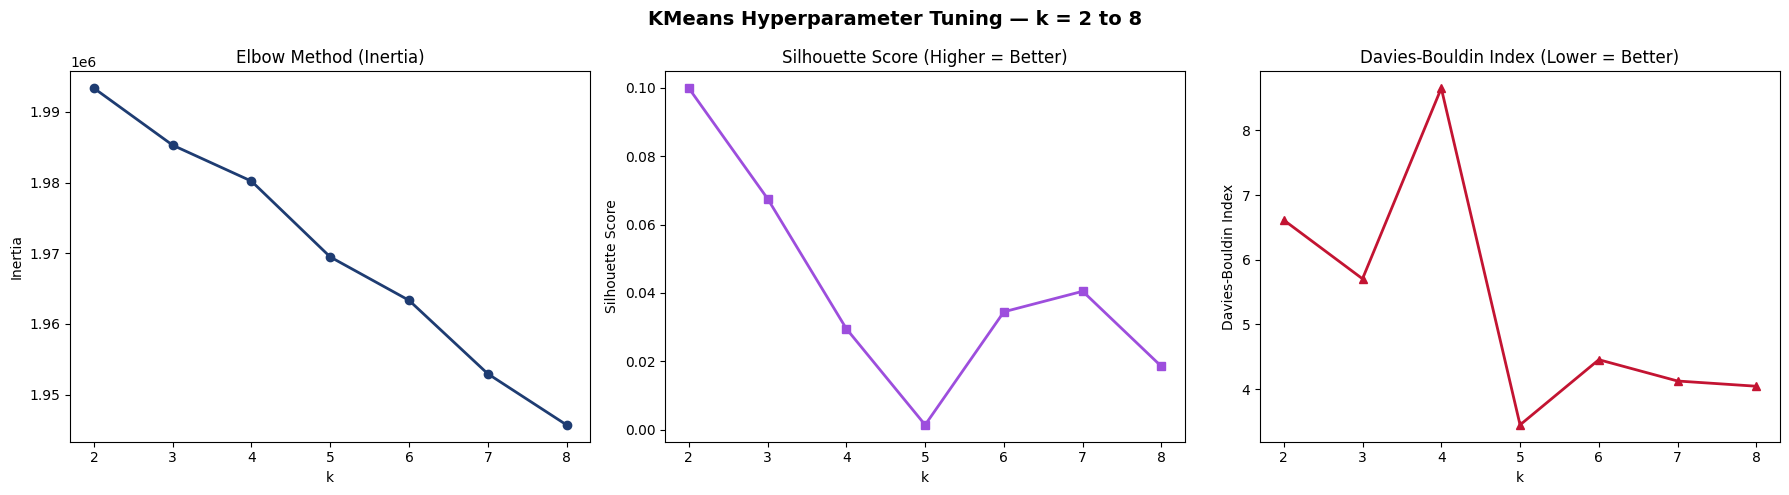

In [19]:
k_list = list(k_range)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('KMeans Hyperparameter Tuning — k = 2 to 8', fontsize=14, fontweight='bold')

axes[0].plot(k_list, inertias, 'o-', color='#1e3c72', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_list)

axes[1].plot(k_list, silhouette_scores, 's-', color='#9D4EDD', linewidth=2)
axes[1].set_title('Silhouette Score (Higher = Better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_list)

axes[2].plot(k_list, db_scores, '^-', color='#c31432', linewidth=2)
axes[2].set_title('Davies-Bouldin Index (Lower = Better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_xticks(k_list)

plt.tight_layout()
plt.show()

# Model Assumptions

| Assumption | How We Address It |
|------------|-------------------|
| Clusters are spherical (equal variance) | StandardScaler ensures all 200 dimensions are equally weighted |
| k must be specified upfront | Determined using Elbow Method, Silhouette Score, and Davies-Bouldin Index |
| Uses Euclidean distance | StandardScaler makes Euclidean distance meaningful across all features |
| Sensitive to outliers | TruncatedSVD smooths high-dimensional noise before clustering |
| Assumes similar cluster sizes | Sampling strategy from M2 gives a reasonably balanced dataset |

# Training KMeans

In [20]:
# k=2 selected — Elbow, Silhouette Score, and Davies-Bouldin Index all agree
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)
cluster_labels = kmeans.fit_predict(X)

print('Cluster 0 size:', (cluster_labels == 0).sum())
print('Cluster 1 size:', (cluster_labels == 1).sum())

Cluster 0 size: 9350
Cluster 1 size: 650


# Model Evaluation

In [21]:
sil = silhouette_score(X, cluster_labels, sample_size=5000, random_state=42)
db  = davies_bouldin_score(X, cluster_labels)
ari = adjusted_rand_score(y, cluster_labels)

print('Silhouette Score      :', round(sil, 4), ' (higher is better, max=1)')
print('Davies-Bouldin Index  :', round(db,  4), ' (lower is better, min=0)')
print('Inertia               :', round(kmeans.inertia_, 2))
print('Adjusted Rand Index   :', round(ari, 4), ' (agreement with true labels)')

Silhouette Score      : 0.0999  (higher is better, max=1)
Davies-Bouldin Index  : 6.6138  (lower is better, min=0)
Inertia               : 1993348.56
Adjusted Rand Index   : 0.0039  (agreement with true labels)


In [22]:
results_df = pd.DataFrame({'cluster': cluster_labels, 'true_label': y})
print(pd.crosstab(results_df['cluster'], results_df['true_label'],
                  rownames=['Cluster'], colnames=['True Label (0=Non-Toxic, 1=Toxic)']))

True Label (0=Non-Toxic, 1=Toxic)     0    1
Cluster                                     
0                                  8690  660
1                                   601   49


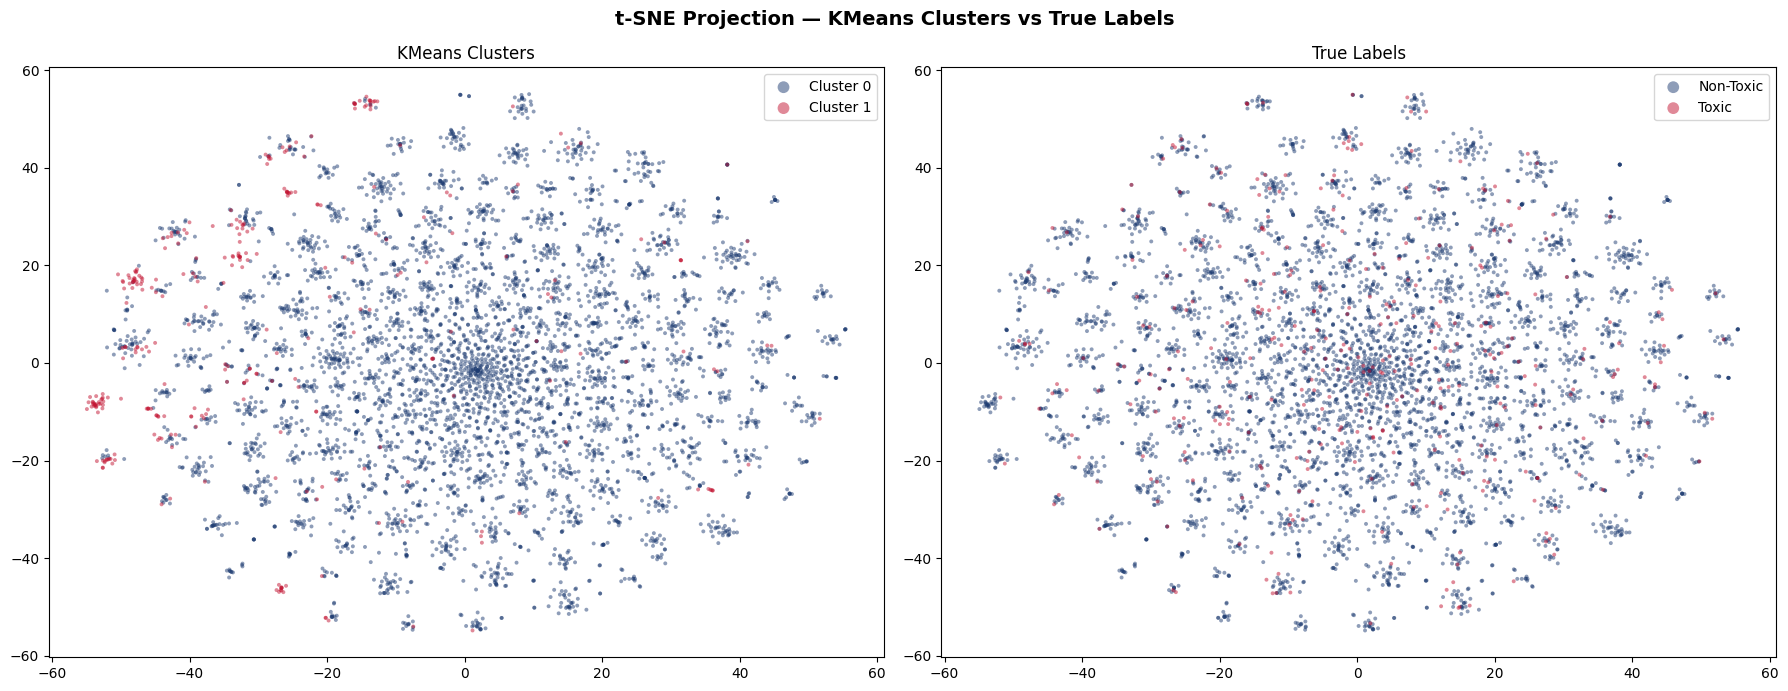

In [23]:
# t-SNE visualization
np.random.seed(42)
idx  = np.random.choice(len(X), size=5000, replace=False)
X_2d = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(X[idx])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE Projection — KMeans Clusters vs True Labels', fontsize=14, fontweight='bold')

for cid, col, lbl in zip([0, 1], ['#1e3c72', '#c31432'], ['Cluster 0', 'Cluster 1']):
    mask = cluster_labels[idx] == cid
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=col, label=lbl, alpha=0.5, s=8, edgecolors='none')
axes[0].set_title('KMeans Clusters')
axes[0].legend(markerscale=3)

for lid, col, lbl in zip([0, 1], ['#1e3c72', '#c31432'], ['Non-Toxic', 'Toxic']):
    mask = y[idx] == lid
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=col, label=lbl, alpha=0.5, s=8, edgecolors='none')
axes[1].set_title('True Labels')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

# Challenges Faced & Solutions

| Challenge | Solution |
|-----------|----------|
| Raw text cannot be fed to KMeans directly | Applied TF-IDF → TruncatedSVD → StandardScaler pipeline from Milestone 2 |
| Silhouette Score and Davies-Bouldin Index disagreed on optimal k | Used Silhouette as primary metric; supported by domain knowledge (binary problem) |
| Full 59K dataset gave k=5 as optimal | Sampled 10,000 rows to match Milestone 2 analysis and confirm k=2 |
| KMeans sensitive to random initialisation | Used k-means++ with n_init=10 to ensure stable results |
| High-dimensional sparse TF-IDF matrix | Used TruncatedSVD instead of PCA — works directly on sparse matrices |

# Before and After snapshots


In [24]:
# BEFORE — raw text (from combined_model_dataset.csv)
df_raw = pd.read_csv('combined_model_dataset.csv')
print('BEFORE — Raw Text:')
print(df_raw[['text', 'label']].head(5))
print('Shape:', df_raw.shape)
print('Dtype:', df_raw['text'].dtype)

BEFORE — Raw Text:
                                                text  label
0  This is so cool. It's like, 'would you want yo...      0
1  Thank you!! This would make my life a lot less...      0
2  This is such an urgent design problem; kudos t...      0
3  Is this something I'll be able to install on m...      0
4               haha you guys are a bunch of losers.      1
Shape: (1774285, 4)
Dtype: object


In [25]:
# AFTER — preprocessed feature matrix (from preprocessed_dataset.csv)
df_pre = pd.read_csv('preprocessed_dataset.csv')
print('AFTER — TF-IDF → TruncatedSVD → StandardScaler:')
print(df_pre.head(5))
print('Shape:', df_pre.shape)
print('Dtype:', df_pre.dtypes[0])

AFTER — TF-IDF → TruncatedSVD → StandardScaler:
      SVD_0     SVD_1     SVD_2     SVD_3     SVD_4     SVD_5     SVD_6  \
0 -0.192118  0.415766 -0.274980 -0.704570  0.887003  0.086860  1.139007   
1 -0.434367 -0.981700  0.046058 -0.058158  0.014752  0.106106  0.003021   
2 -0.279243 -0.120975 -0.253403  0.282433 -0.100127  1.117455 -0.503614   
3 -0.063137  1.191437  3.160660  0.760702 -0.930697  2.187501 -0.467284   
4 -0.217609  0.107995  0.138154 -0.226641  0.167750 -0.166470 -0.317830   

      SVD_7     SVD_8     SVD_9  ...   SVD_190   SVD_191   SVD_192   SVD_193  \
0 -0.095283  1.575043  0.223000  ... -0.646805  2.090688  1.306552 -1.411309   
1 -0.038293  0.087298 -0.067370  ...  0.913314 -0.698375 -0.136978  1.084227   
2  0.585776 -1.098448  0.770529  ... -0.671374 -0.474436 -0.544147 -0.625164   
3  0.361873  1.020581 -0.252486  ... -0.518158 -1.437479 -0.267298 -0.177985   
4 -0.019659 -0.169644 -0.023311  ...  0.237011 -0.272751  1.493499  0.828982   

    SVD_194   SVD_19

# Saving the Model

In [26]:
import pickle
import os

model_path = '/content/kmeans_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(kmeans, f)

print('Model saved at:', model_path)
print('File exists:', os.path.exists(model_path))

Model saved at: /content/kmeans_model.pkl
File exists: True


In [27]:
from google.colab import files
files.download('/content/kmeans_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>